In [13]:
import pandas as pd
import thebeat
import os
import matplotlib.pyplot as plt

In [5]:
# Load ITIs df
df = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs.csv'))
df_bytrial = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs_bytrial.csv'))

In [52]:
# Get ITIs of 9 sequences with the highest entropy difference

highest_entropy = df_bytrial.nlargest(9, 'entropy_diff').sequence_id.values
lowest_entropy = df_bytrial.nsmallest(9, 'entropy_diff').sequence_id.values
zero_entropy = df_bytrial[df_bytrial['entropy_diff'] == 0].sample(9).sequence_id.values

print(highest_entropy)

# Get ITIs of 9 sequences with the highest entropy difference
#highest_entropy_itis = df[df['sequence_id'].isin(highest_entropy)]
#lowest_entropy_itis = df[df['sequence_id'].isin(lowest_entropy)].copy()
#zero_entropy_itis = df[df['sequence_id'].isin(zero_entropy)].copy()



['24_93' '24_94' '24_95' '27_174' '27_175' '27_176' '32_167' '32_168'
 '32_169']


# Highest entropy event plots

Text(0.5, 0.98, 'Sequences with highest entropy')

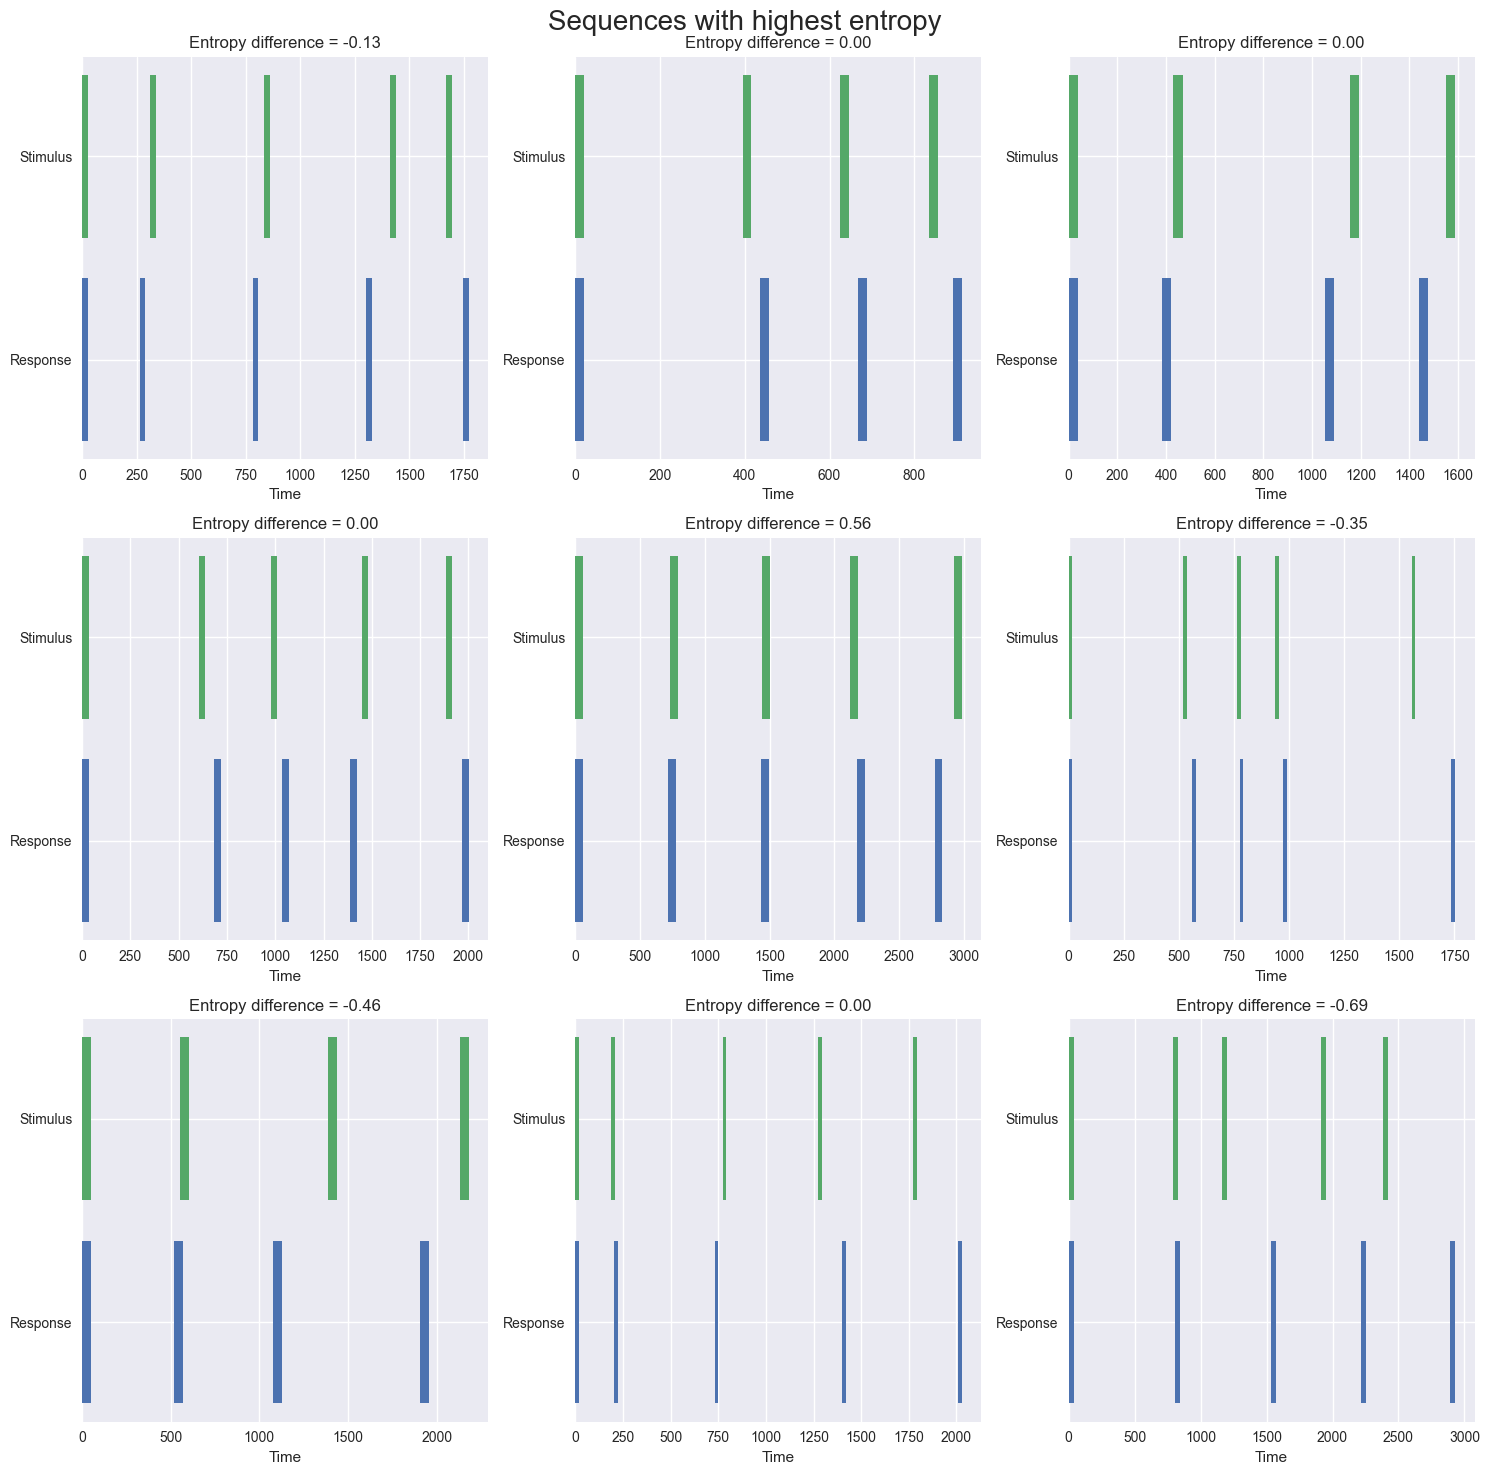

In [48]:
# Plot ITIs by sequence_id

plt.style.use('seaborn-v0_8')

fig, axs = plt.subplots(3, 3, figsize=(15, 15), tight_layout=True)

count = 0

for seq_id, seq_df in highest_entropy_itis.groupby('sequence_id'):
    resp_seq = thebeat.Sequence(seq_df.resp_iti.values)
    stim_seq = thebeat.Sequence(seq_df.stim_ioi.values)
    thebeat.visualization.plot_multiple_sequences([stim_seq, resp_seq], y_axis_labels=['Stimulus', 'Response'],
    title=f"Entropy difference = {seq_df.entropy_diff.values[0]:.2f}",
                                                   ax=axs[count // 3, count % 3])

    count += 1

fig.suptitle('Sequences with highest entropy', fontsize=20)

# Sequences with lowest entropy

Text(0.5, 0.98, 'Sequences with most negative entropy difference')

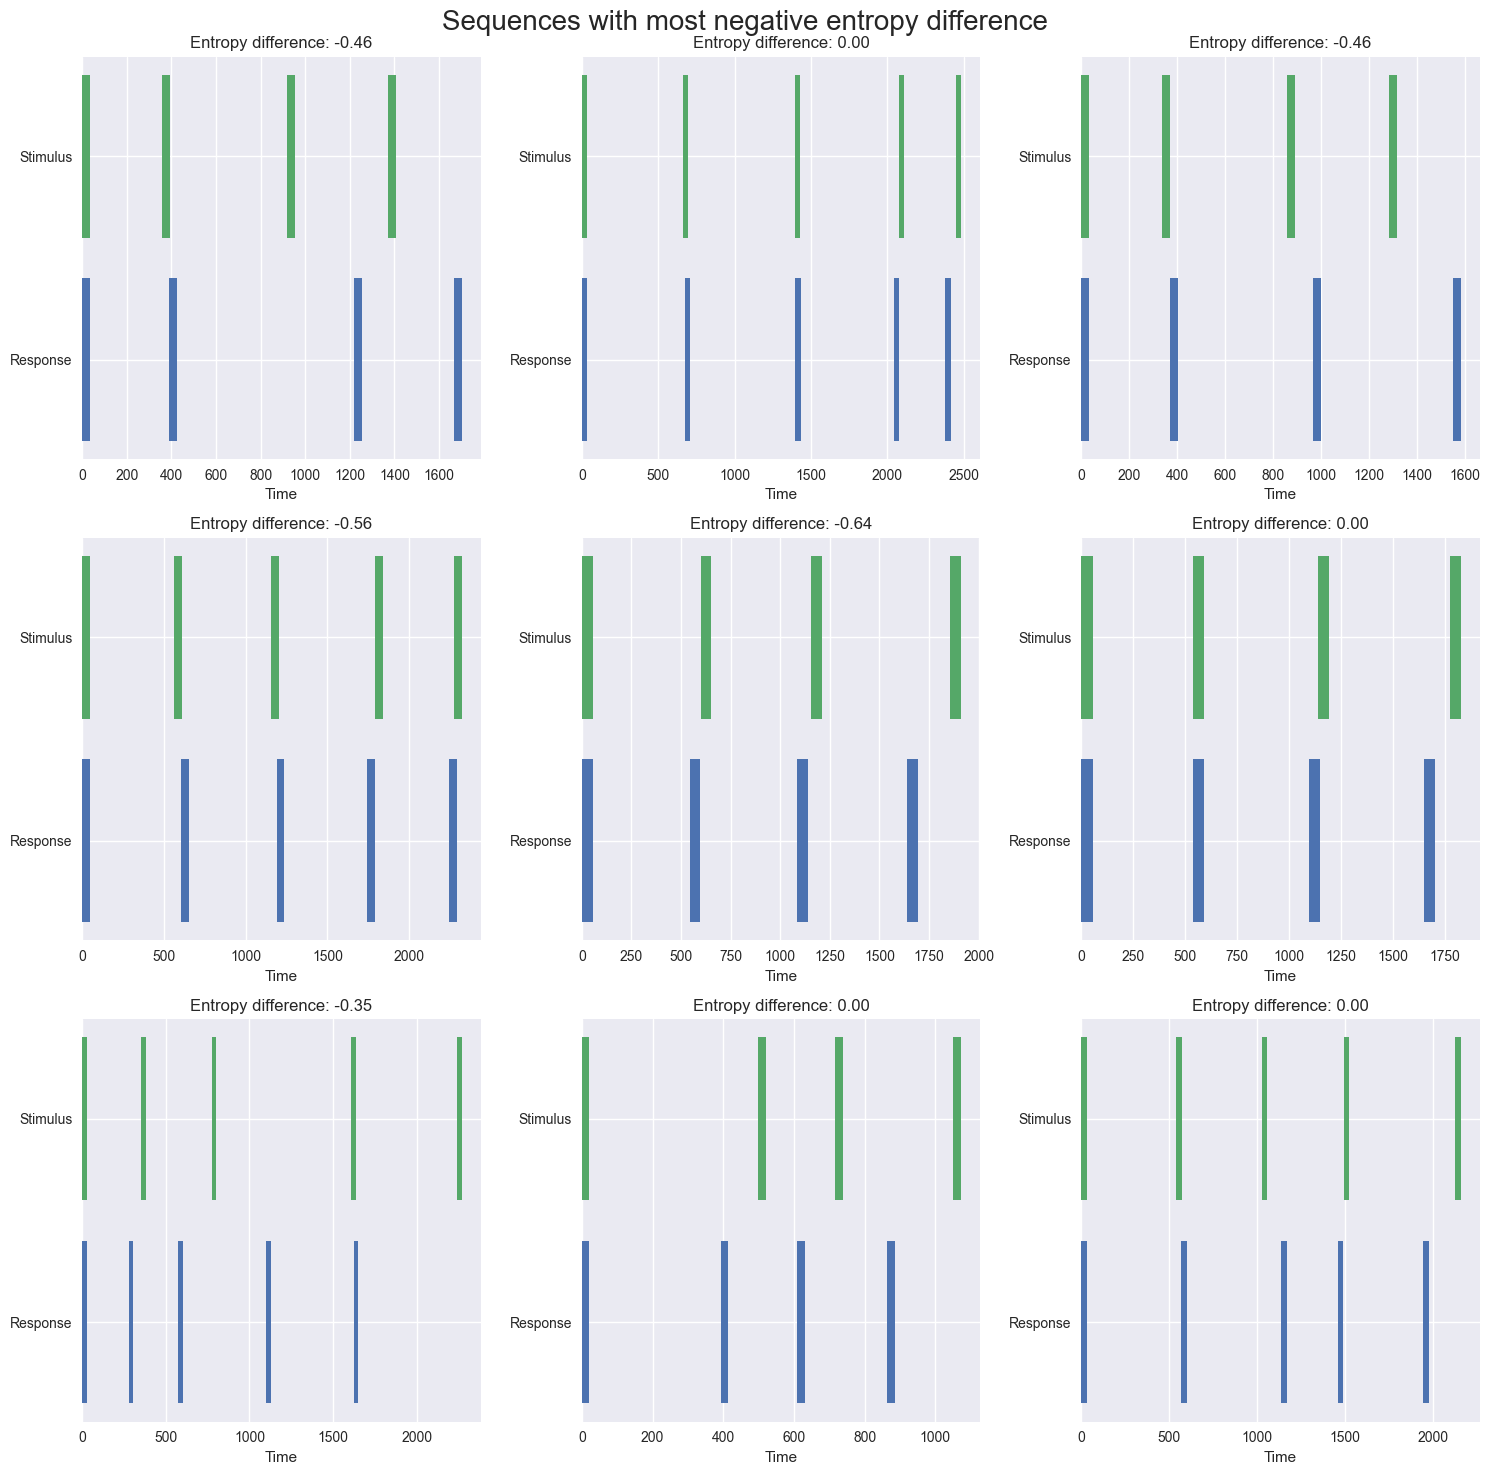

In [22]:
# Plot ITIs by sequence_id

plt.style.use('seaborn-v0_8')

fig, axs = plt.subplots(3, 3, figsize=(15, 15), tight_layout=True)

count = 0

for seq_id, seq_df in lowest_entropy_itis.groupby('sequence_id'):
    resp_seq = thebeat.Sequence(seq_df.resp_iti.values)
    stim_seq = thebeat.Sequence(seq_df.stim_ioi.values)
    thebeat.visualization.plot_multiple_sequences([stim_seq, resp_seq],
                                                  title = f"Entropy difference: {seq_df.entropy_diff.values[0]:.2f}",
                                                  y_axis_labels=['Stimulus', 'Response'],
                                                   ax=axs[count // 3, count % 3])

    count += 1

fig.suptitle('Sequences with most negative entropy difference', fontsize=20)